---
title: "MPG"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Auto MPG
- **description:** Fuel efficiency and engine attributes for 398 automobile models from the 1970–1982 model years.
- **provenance:** UCI Machine Learning Repository, "Auto MPG"; originally from the StatLib library and the 1983 ASA Data Exposition.
- **format:** long / tidy — 398 rows x 9 columns.

**Data dictionary**

- `mpg` — *(measurement)* fuel efficiency in miles per gallon.
- `cylinders` — *(measurement)* number of cylinders.
- `displacement` — *(measurement)* engine displacement (cubic inches).
- `horsepower` — *(measurement)* engine horsepower (a few values missing).
- `weight` — *(measurement)* vehicle weight in pounds.
- `acceleration` — *(measurement)* seconds to accelerate 0–60 mph.
- `model_year` — *(identifier)* model year (70–82).
- `origin` — *(identifier)* region of origin (`usa`, `europe`, `japan`).
- `name` — *(identifier)* the car's name.

**Structure**

- **Rows:** 398 — one row per car model.
- **Columns:** 9.
- **Identifiers:** `origin`, `model_year`, `name`.
- **Measurements:** `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`.

**Use cases**

- scatter matrices of engine attributes
- grouped aggregation by origin and model year
- z-score normalization for cross-measure comparison


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

In [2]:
mpg = sns.load_dataset('mpg')
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


## Long form with key index

In [3]:
mpg1 = mpg.set_index(['name'])
mpg1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86.0,2790,15.6,82,usa
vw pickup,44.0,4,97.0,52.0,2130,24.6,82,europe
dodge rampage,32.0,4,135.0,84.0,2295,11.6,82,usa


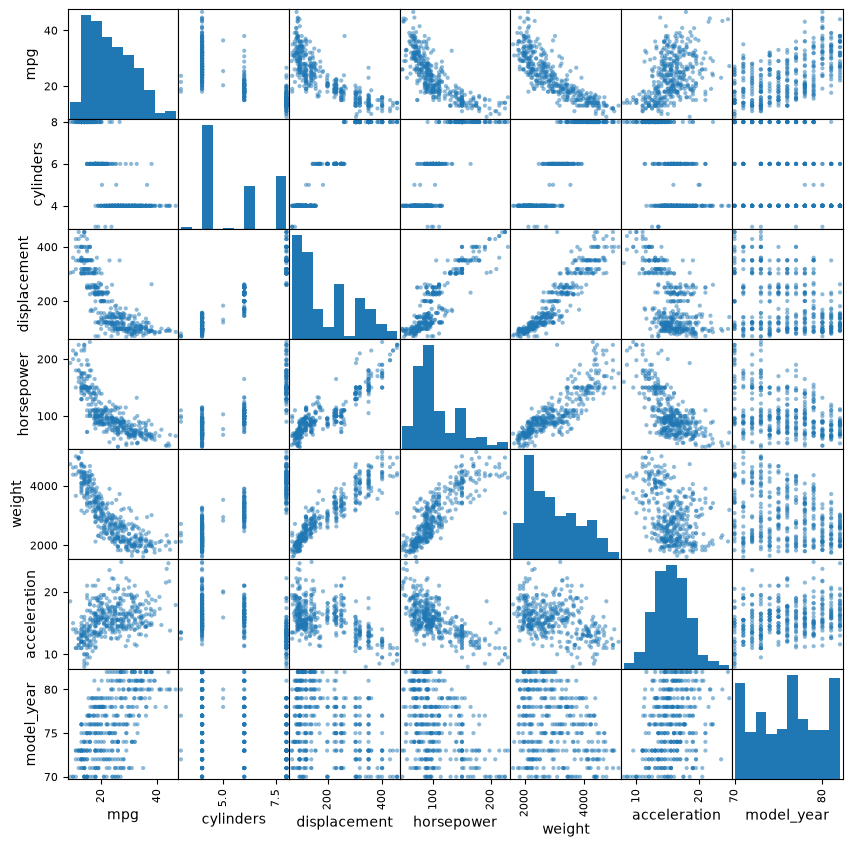

In [14]:
pd.plotting.scatter_matrix(mpg1, figsize=(10,10))
plt.show()

## Long form aggregate of all measures by joint nominals with multiple aggfuncs

In [15]:
mpg_nominals = ['model_year', 'origin']
mpg_measures = list(mpg1.columns)[:-2]
mpg2 = mpg1.groupby(mpg_nominals)[mpg_measures].agg(['mean','min','max'])
mpg2

mpg             cylinders         displacement  \
                        mean   min   max      mean min max         mean   
model_year origin                                                         
70         europe  25.200000  24.0  26.0  4.000000   4   4   107.800000   
           japan   25.500000  24.0  27.0  4.000000   4   4   105.000000   
           usa     15.272727   9.0  22.0  7.636364   6   8   336.909091   
71         europe  28.750000  27.0  30.0  4.000000   4   4    95.000000   
           japan   29.500000  25.0  35.0  4.000000   4   4    88.250000   
           usa     18.100000  12.0  28.0  6.200000   4   8   257.000000   
72         europe  22.000000  18.0  26.0  4.000000   4   4   111.000000   
           japan   24.200000  19.0  28.0  3.800000   3   4    99.400000   
           usa     16.277778  11.0  28.0  6.888889   4   8   281.250000   
73         europe  24.000000  19.0  29.0  4.000000   4   4   105.000000   
           japan   20.000000  18.0  22.0  4.250000   3   6   107.750000   
           usa     15.034483  11.0  23.0  7.241379   4   8   314.103448   
74         europe  27.000000  24.0  31.0  4.000000   4   4    93.166667   
           japan   29.333333  24.0  32.0  4.000000   4   4    89.500000   
           usa     18.333333  13.0  28.0  6.266667   4   8   236.066667   
75         europe  24.500000  22.0  29.0  4.000000   4   4   109.500000   
           japan   27.500000  24.0  33.0  4.000000   4   4   110.250000   
           usa     17.550000  13.0  23.0  6.400000   4   8   253.400000   
76         europe  24.250000  16.5  29.5  4.250000   4   6   116.125000   
           japan   28.000000  19.0  33.0  4.500000   4   6   107.250000   
           usa     19.431818  13.0  29.0  6.363636   4   8   243.954545   
77         europe  29.250000  21.5  36.0  4.000000   4   4    98.500000   
           japan   27.416667  21.5  33.5  4.166667   3   6   100.500000   
           usa     20.722222  15.0  33.5  6.222222   4   8   242.333333   
78         europe  24.950000  16.2  43.1  4.833333   4   6   126.166667   
           japan   29.687500  21.1  39.4  4.000000   4   4   107.250000   
           usa     21.772727  17.5  36.1  6.000000   4   8   217.545455   
79         europe  30.450000  25.4  37.3  4.250000   4   5   126.000000   
           japan   32.950000  31.8  34.1  4.000000   4   4    85.500000   
           usa     23.478261  15.5  35.7  6.260870   4   8   231.260870   
80         europe  37.288889  29.8  44.3  4.111111   4   5   104.222222   
           japan   35.400000  23.7  46.6  4.076923   3   6   104.615385   
           usa     25.914286  19.1  32.1  4.285714   4   6   151.571429   
81         europe  31.575000  28.1  34.5  4.500000   4   6   122.750000   
           japan   32.958333  24.2  39.1  4.333333   4   6   107.500000   
           usa     27.530769  17.6  39.0  4.923077   4   8   164.846154   
82         europe  40.000000  36.0  44.0  4.000000   4   4   101.000000   
           japan   34.888889  31.0  38.0  4.000000   4   4   103.777778   
           usa     29.450000  22.0  38.0  4.300000   4   6   142.950000   

                                 horsepower                    weight        \
                     min    max        mean   min    max         mean   min   
model_year origin                                                             
70         europe   97.0  121.0   86.200000  46.0  113.0  2309.200000  1835   
           japan    97.0  113.0   91.500000  88.0   95.0  2251.000000  2130   
           usa     198.0  455.0  166.954545  85.0  225.0  3716.500000  2587   
71         europe   79.0  116.0   74.000000  60.0   90.0  2024.000000  1834   
           japan    71.0  113.0   79.250000  65.0   95.0  1936.000000  1613   
           usa      91.0  400.0  119.842105  70.0  180.0  3401.600000  1955   
72         europe   96.0  121.0   79.600000  54.0  112.0  2573.200000  2189   
           japan    70.0  120.0   93.800000  88.0   97.0  2300.400000  2100   
     

## Wide form, aggregate one measure by two nominals

With `mpg2`, we can access wide table respresenations of any aggregregated feature by simple column selection and unstacking.

In [16]:
mpg_feature = 'mpg'
mpg_aggfunc = 'mean'
mpg3a = mpg2[(mpg_feature, mpg_aggfunc)].unstack()
mpg3a

origin,europe,japan,usa
model_year,,,
70,25.200000,25.500000,15.272727
71,28.750000,29.500000,18.100000
72,22.000000,24.200000,16.277778
73,24.000000,20.000000,15.034483
74,27.000000,29.333333,18.333333
75,24.500000,27.500000,17.550000
76,24.250000,28.000000,19.431818
77,29.250000,27.416667,20.722222
78,24.950000,29.687500,21.772727


In [7]:
mpg_feature = 'horsepower'
mpg_aggfunc = 'mean'
mpg3b = mpg2[(mpg_feature, mpg_aggfunc)].unstack()
mpg3b

origin,europe,japan,usa
model_year,,,
70,86.200000,91.500000,166.954545
71,74.000000,79.250000,119.842105
72,79.600000,93.800000,138.777778
73,81.857143,98.500000,146.620690
74,74.166667,72.500000,112.142857
75,89.500000,80.250000,108.700000
76,87.625000,76.500000,110.500000
77,81.000000,81.166667,118.388889
78,99.166667,79.250000,107.272727


Getting the same result from `mpg1`.

In [8]:
mpg1.groupby(['model_year', 'origin'])[mpg_feature].agg(mpg_aggfunc).unstack()

origin,europe,japan,usa
model_year,,,
70,86.200000,91.500000,166.954545
71,74.000000,79.250000,119.842105
72,79.600000,93.800000,138.777778
73,81.857143,98.500000,146.620690
74,74.166667,72.500000,112.142857
75,89.500000,80.250000,108.700000
76,87.625000,76.500000,110.500000
77,81.000000,81.166667,118.388889
78,99.166667,79.250000,107.272727


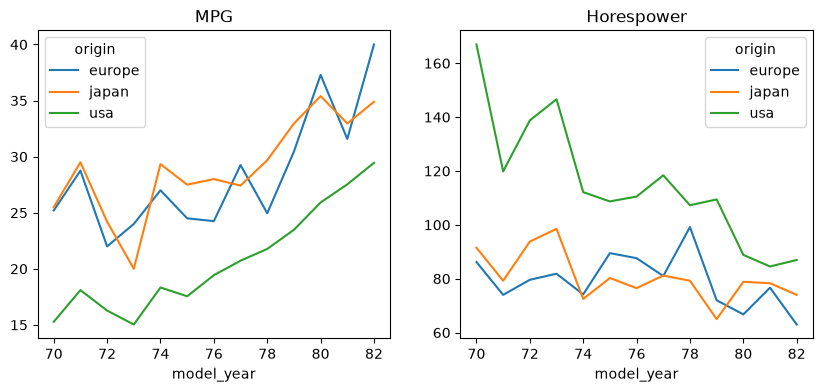

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
mpg3a.plot(ax=ax[0], title="MPG")
mpg3b.plot(ax=ax[1], title="Horespower")
plt.show()

## Wide form aggregate of all measures by one nominal

In [10]:
mpg4a = mpg1.groupby('model_year')[mpg_measures].mean()
mpg4a

,mpg,cylinders,displacement,horsepower,weight,acceleration
model_year,,,,,,
70,17.689655,6.758621,281.413793,147.827586,3372.793103,12.948276
71,21.250000,5.571429,209.750000,107.037037,2995.428571,15.142857
72,18.714286,5.821429,218.375000,120.178571,3237.714286,15.125000
73,17.100000,6.375000,256.875000,130.475000,3419.025000,14.312500
74,22.703704,5.259259,171.740741,94.230769,2877.925926,16.203704
75,20.266667,5.600000,205.533333,101.066667,3176.800000,16.050000
76,21.573529,5.647059,197.794118,101.117647,3078.735294,15.941176
77,23.375000,5.464286,191.392857,105.071429,2997.357143,15.435714
78,24.061111,5.361111,177.805556,99.694444,2861.805556,15.805556


In [11]:
mpg4b = mpg1.groupby('origin')[mpg_measures].mean()
mpg4b

,mpg,cylinders,displacement,horsepower,weight,acceleration
origin,,,,,,
europe,27.891429,4.157143,109.142857,80.558824,2423.300000,16.787143
japan,30.450633,4.101266,102.708861,79.835443,2221.227848,16.172152
usa,20.083534,6.248996,245.901606,119.048980,3361.931727,15.033735


## Wide form normed by z-score

Norming the data in a dataframe with multiple features allows us to compare trends.

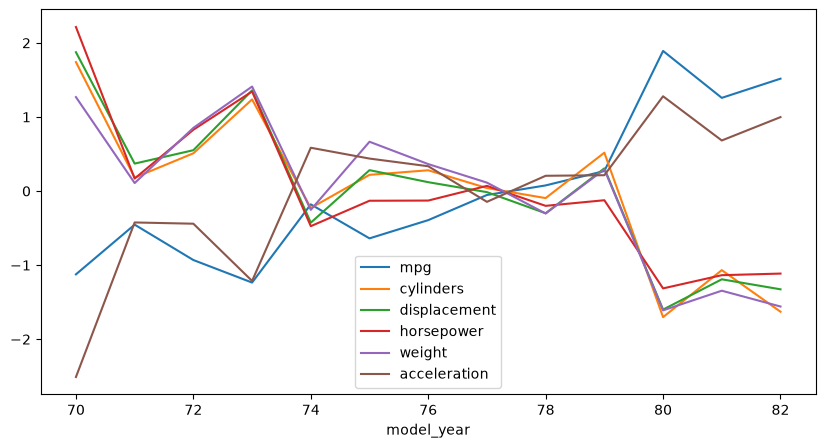

In [12]:
((mpg4a - mpg4a.mean()) / mpg4a.std()).plot(figsize=(10, 5))
plt.show()

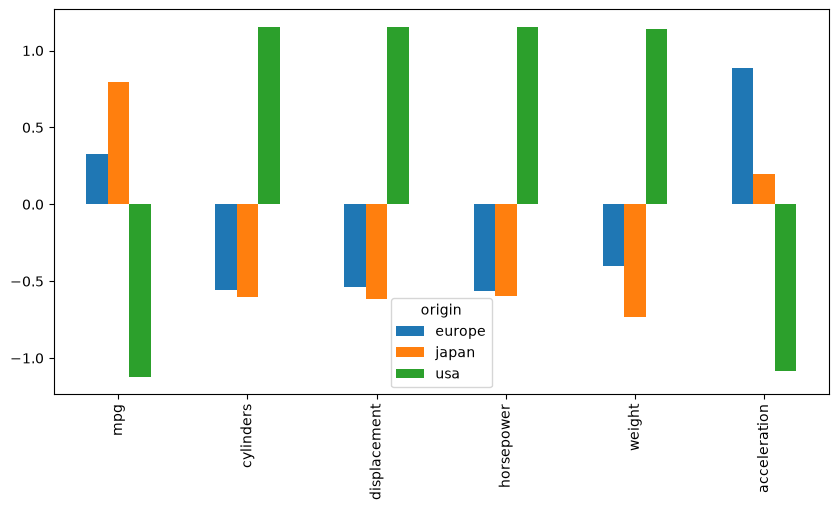

In [13]:
((mpg4b - mpg4b.mean()) / mpg4b.std()).T.plot.bar(figsize=(10, 5))
plt.show()